In [5]:
'''Midlatitude Summer'''
import importlib
import final_forward_attenuation
importlib.reload(final_forward_attenuation)
from final_forward_attenuation import run_simulation, default_species, convert_atm, convert_vmr
Ptotal = convert_atm(1.013e6, "gcms2") 
ppVs = [1.876E-02, 3.300E-04, 3.017E-08, 3.200E-07, 1.500E-07, 1.700E-06, 0.781] #porque no usamos N2?
o2 = convert_vmr(2.090E+05)
vmrs = ppVs + [o2]
print(vmrs)

[0.01876, 0.00033, 3.017e-08, 3.2e-07, 1.5e-07, 1.7e-06, 0.781, 0.209]


In [7]:
print(f'Total pressure (atm): {Ptotal}')

Total pressure (atm): 0.999753269183321


c:\Users\PC\Documents\GitHub\Stand-off
DEBUG: H2O qfile=TIPS/q1.txt exists=True
DEBUG: CO2 qfile=TIPS/q7.txt exists=True
DEBUG: O3 qfile=TIPS/q16.txt exists=True
DEBUG: N2O qfile=TIPS/q21.txt exists=True
DEBUG: CO qfile=TIPS/q26.txt exists=True
DEBUG: CH4 qfile=TIPS/q32.txt exists=True
DEBUG: O2 qfile=TIPS/q36.txt exists=True


c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(qfile, header=None, delim_whitespace=True, comment='#')
c:\Users\PC\Documents\GitHub\Stand-off\final_forward_attenuation.py:47: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv 

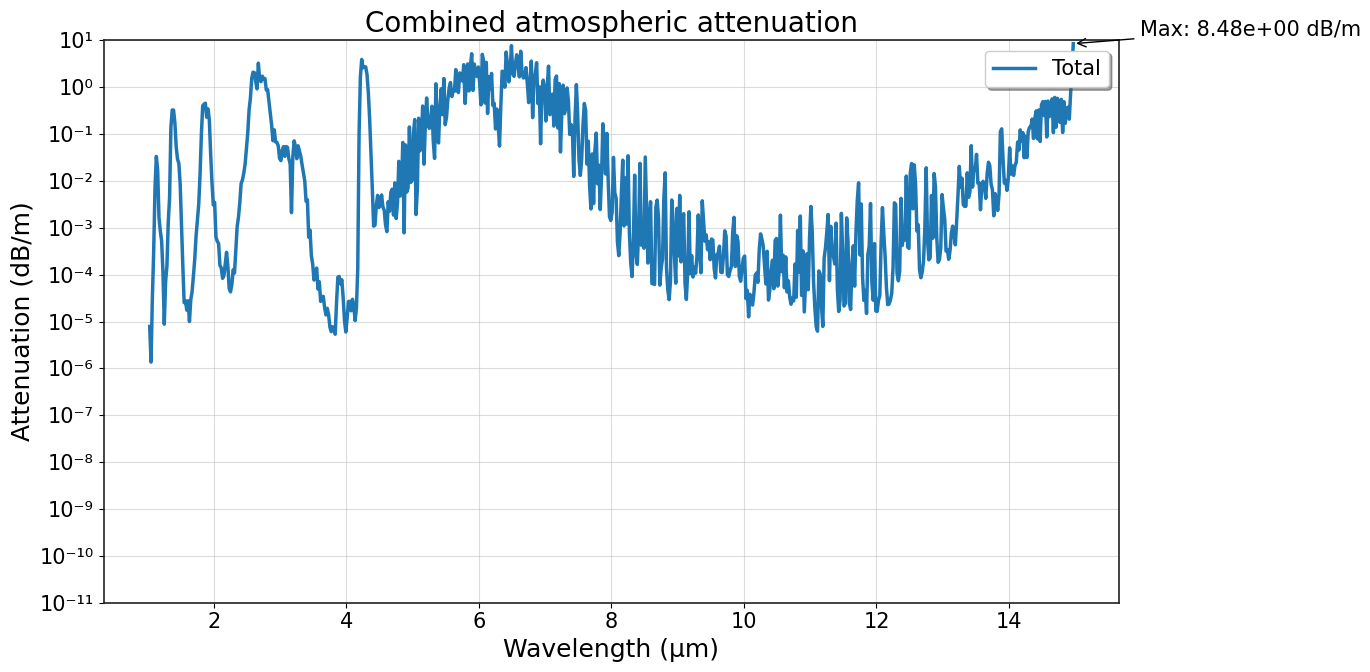

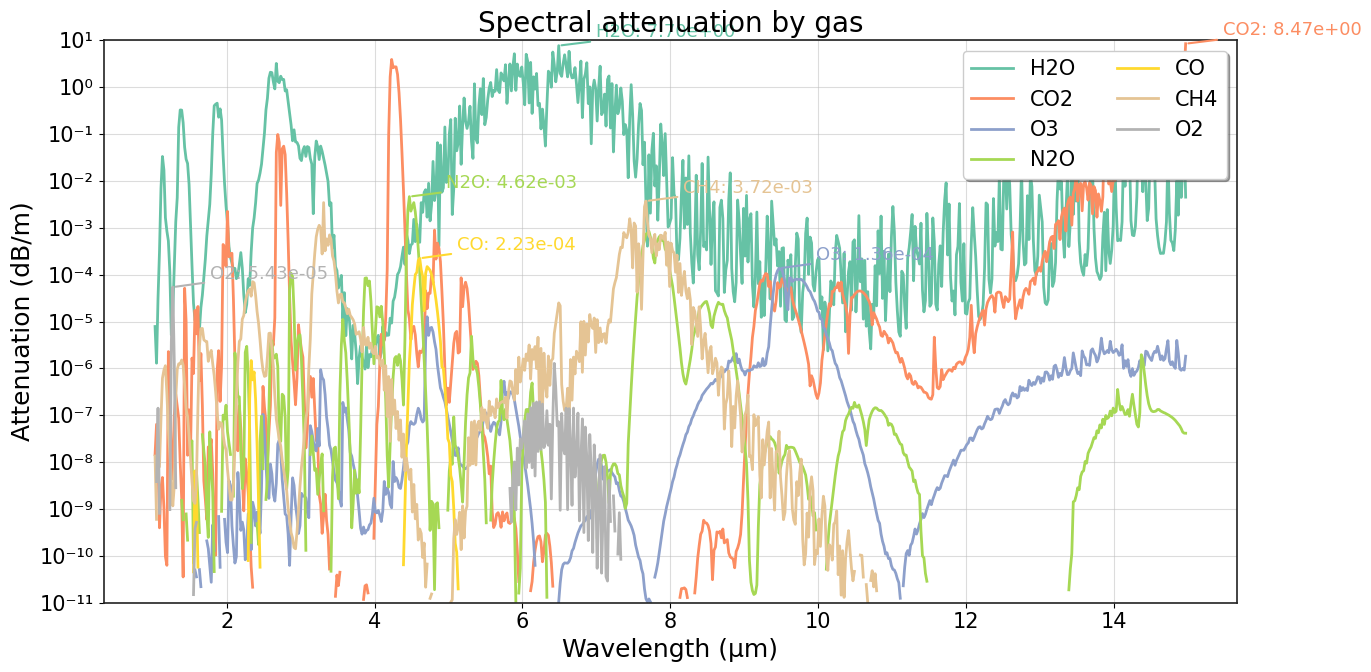

In [9]:
#1 km
sp = default_species()
for s in sp:
     if s.name == 'CH4': s.Pmol = 1.6995805576116458e-06


import os
print(os.getcwd())

res = run_simulation(
    parfile='68da838c.par',
    species=sp,
    nu_min=666.67, nu_max=10000.0, dnu=0.01,
    tileW=20.0, guard=5.0,
    temp_K=296.0, L_m=1.0, pres=Ptotal,
    delta_um=0.020,
    save_csv=True, outdir='out', make_plots=True,
)

lambda_um = res['lambda_centers']
Tprod = res['T_prod_samp']
Th2o  = res['T_each_samp'][0]